<a href="https://colab.research.google.com/github/milo77777666/NTHU_2025_DLBOI/blob/main/114011530_%E8%AC%9D%E6%94%BF%E7%B4%98_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task B:ResNet18

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 79.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

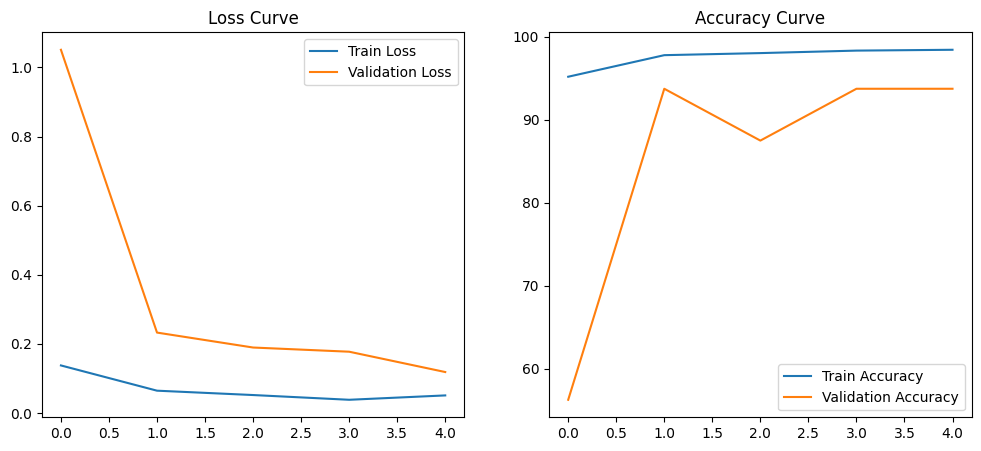

Test Accuracy: 76.60%
Test Loss: 0.5889


In [3]:

#IMPORTS
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optims

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms.functional import InterpolationMode
from torchvision.models import resnet18, ResNet18_Weights  #ResNet18


#DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

#Google Drive
from google.colab import drive
drive.mount('/content/drive')


#資料夾路徑
train_path = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
val_path   = '/content/drive/MyDrive/Colab Notebooks/chest_xray/val'
test_path  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'


#Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),  # ResNet 需要 3 channels
    transforms.ToTensor(),
])

common_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


#Datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_path,   transform=common_transform)
test_dataset  = datasets.ImageFolder(test_path,  transform=common_transform)

print("Train classes:", train_dataset.classes)
print("Val classes:",   val_dataset.classes)
print("Test classes:",  test_dataset.classes)

#DataLoaders（batch_size=16）
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

#建立ResNet18模型（修改最後一層）
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

#修改最後的FC
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 1),
    nn.Sigmoid()
)

model = model.to(device)
print(model)

#Hyperparameters
lr = 0.001
weight_decay = 0.0001
epochs = 5

optimizer = optims.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.BCELoss()

lr_scheduler = optims.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=3, mode='max'
)

save = 'resnet18_hw4'


#訓練一個epoch
def train_one_epoch(model, device, criterion, optimizer, train_loader):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.train()

    for images, labels in train_loader:

        #釋放Colab RAM
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels.unsqueeze(1))

        epoch_loss.append(loss.item())

        predicts = (preds > 0.5).float().view(-1).cpu().numpy()
        acc = accuracy_score(labels.cpu().numpy(), predicts)
        epoch_acc.append(acc)

        loss.backward()
        optimizer.step()

    return np.mean(epoch_loss), np.mean(epoch_acc)*100, time.time() - start

#驗證一個epoch
def val_one_epoch(model, device, criterion, val_loader, best_acc, save):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            epoch_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            epoch_acc.append(acc)

    avg_acc = np.mean(epoch_acc) * 100

    #儲存最佳模型
    if avg_acc > best_acc:
        best_acc = avg_acc
        torch.save(model.state_dict(), f"{save}.pth")
        print(f"  >> Best Model Updated (Val Acc = {best_acc:.2f}%)")

    return np.mean(epoch_loss), avg_acc, time.time() - start, best_acc

# 測試 evaluate
def evaluate(model, device, model_path, test_loader):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    test_loss, test_acc = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            test_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            test_acc.append(acc)

    print(f"Test Accuracy: {np.mean(test_acc)*100:.2f}%")
    print(f"Test Loss: {np.mean(test_loss):.4f}")

    return np.mean(test_loss), np.mean(test_acc)*100

#主訓練迴圈
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0

for epoch in range(epochs):
    print(f"\n===== Epoch {epoch+1}/{epochs} =====")

    train_loss, train_acc, train_time = train_one_epoch(model, device, criterion, optimizer, train_loader)
    val_loss, val_acc, val_time, best_acc = val_one_epoch(model, device, criterion, val_loader, best_acc, save)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    lr_scheduler.step(val_acc)

# 畫Loss/Accuracy曲線
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.legend()

plt.show()

#最後測試
model_path = 'resnet18_hw4.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)


In [5]:
model_path = 'resnet18_hw4.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)

Test Accuracy: 76.60%
Test Loss: 0.5889


Task B:EfficientNetV2-s

Using device: cpu
Mounted at /content/drive
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 45.0MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

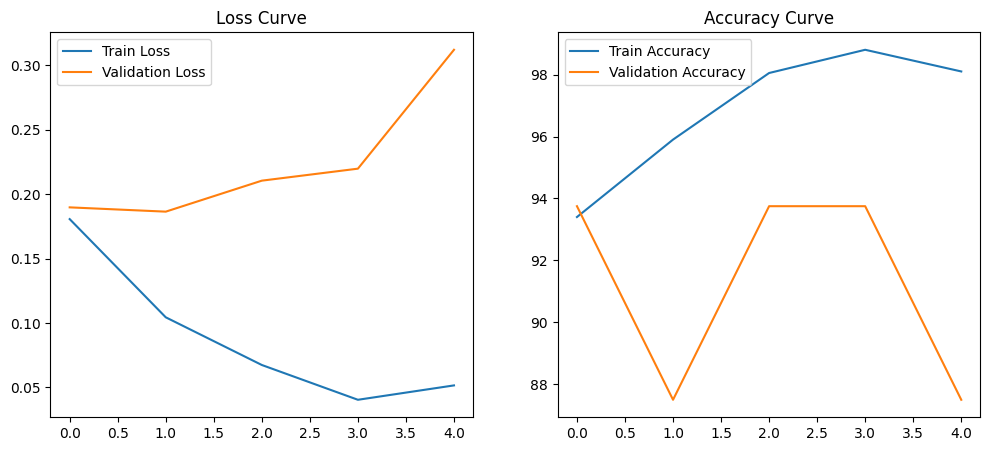

Test Accuracy: 91.51%
Test Loss: 0.2073


In [1]:

#IMPORTS
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optims

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms.functional import InterpolationMode
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights  # ★ EfficientNetV2-S

#DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

#Google Drive
from google.colab import drive
drive.mount('/content/drive')

#資料夾路徑
train_path = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
val_path   = '/content/drive/MyDrive/Colab Notebooks/chest_xray/val'
test_path  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'

#Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),  # ★ 小尺寸
    transforms.Grayscale(num_output_channels=3),  # EfficientNetV2 需要 3 channels
    transforms.ToTensor(),
])

common_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

#Datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_path,   transform=common_transform)
test_dataset  = datasets.ImageFolder(test_path,  transform=common_transform)

print("Train classes:", train_dataset.classes)
print("Val classes:",   val_dataset.classes)
print("Test classes:",  test_dataset.classes)


#DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)


#建立EfficientNetV2-S模型（修改最後一層）
#使用ImageNet預訓練權重
model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

#EfficientNetV2-S的分類頭在model.classifier[1]
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 1),  # 二元分類輸出 1 個值
    nn.Sigmoid()

model = model.to(device)
print(model)

#Hyperparameters
lr = 0.001
weight_decay = 0.0001
epochs = 5

optimizer = optims.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.BCELoss()

lr_scheduler = optims.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=3, mode='max'
)

save = 'efficientnetv2s_hw4'   #儲存模型檔名

#訓練一個epoch
def train_one_epoch(model, device, criterion, optimizer, train_loader):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.train()

    for images, labels in train_loader:

        #避免Colab RAM累積
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels.unsqueeze(1))

        epoch_loss.append(loss.item())

        predicts = (preds > 0.5).float().view(-1).cpu().numpy()
        acc = accuracy_score(labels.cpu().numpy(), predicts)
        epoch_acc.append(acc)

        loss.backward()
        optimizer.step()

    return np.mean(epoch_loss), np.mean(epoch_acc)*100, time.time() - start

#驗證一個epoch
def val_one_epoch(model, device, criterion, val_loader, best_acc, save):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            epoch_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            epoch_acc.append(acc)

    avg_acc = np.mean(epoch_acc) * 100

    #儲存最佳模型
    if avg_acc > best_acc:
        best_acc = avg_acc
        torch.save(model.state_dict(), f"{save}.pth")
        print(f"  >> Best Model Updated (Val Acc = {best_acc:.2f}%)")

    return np.mean(epoch_loss), avg_acc, time.time() - start, best_acc

#測試evaluate
def evaluate(model, device, model_path, test_loader):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    test_loss, test_acc = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            test_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            test_acc.append(acc)

    print(f"Test Accuracy: {np.mean(test_acc)*100:.2f}%")
    print(f"Test Loss: {np.mean(test_loss):.4f}")

    return np.mean(test_loss), np.mean(test_acc)*100

#主訓練迴圈
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0

for epoch in range(epochs):
    print(f"\n===== Epoch {epoch+1}/{epochs} =====")

    train_loss, train_acc, train_time = train_one_epoch(model, device, criterion, optimizer, train_loader)
    val_loss, val_acc, val_time, best_acc = val_one_epoch(model, device, criterion, val_loader, best_acc, save)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    lr_scheduler.step(val_acc)

#畫Loss/Accuracy曲線
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.legend()

plt.show()

#最後測試
model_path = 'efficientnetv2s_hw4.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)


Task C：ResNet18 as Fixed Feature Extractor

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 33.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

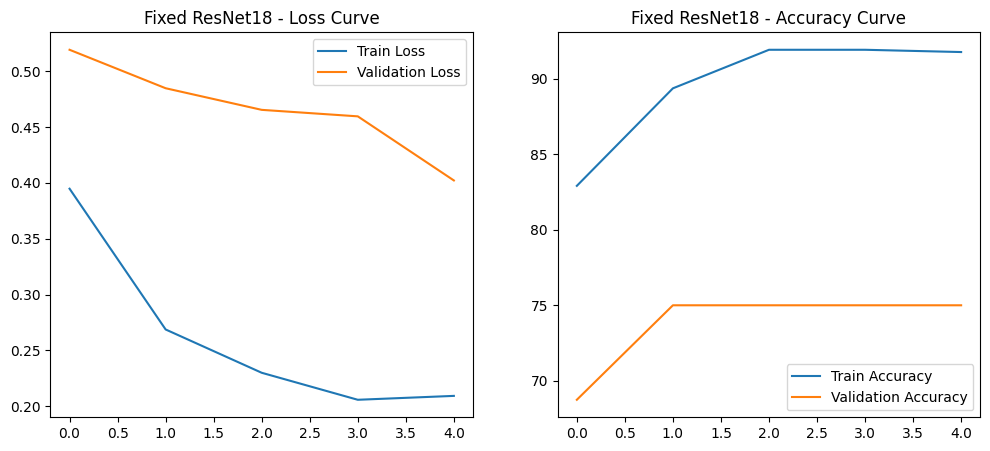

Test Accuracy (Fixed ResNet18): 82.85%
Test Loss: 0.3729


In [3]:

#IMPORTS
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optims

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms.functional import InterpolationMode
from torchvision.models import resnet18, ResNet18_Weights  #ResNet18

# DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


#Google Drive
from google.colab import drive
drive.mount('/content/drive')


#資料夾路徑
train_path = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
val_path   = '/content/drive/MyDrive/Colab Notebooks/chest_xray/val'
test_path  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'


#Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

common_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

#Datasets & DataLoaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_path,   transform=common_transform)
test_dataset  = datasets.ImageFolder(test_path,  transform=common_transform)

print("Train classes:", train_dataset.classes)
print("Val classes:",   val_dataset.classes)
print("Test classes:",  test_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

#建立 ResNet18 模型（Task C：固定特徵抽取器）
# 預訓練權重
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

#修改最後一層為二分類輸出
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 1),
    nn.Sigmoid()
)

# Task C核心：凍結backbone，只訓練最後一層FC
for param in model.parameters():
    param.requires_grad = False          # 先把全部凍結
for param in model.fc.parameters():
    param.requires_grad = True           # 只開放 fc 訓練

model = model.to(device)
print(model)

#Hyperparameters（只更新最後一層參數）
lr = 0.001
weight_decay = 0.0001
epochs = 5

#只把requires_grad=True的參數丟進optimizer
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optims.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
criterion = nn.BCELoss()

lr_scheduler = optims.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=3, mode='max'
)

save = 'resnet18_fixed_hw4'   # Task C model name

#train/val/test loop
def train_one_epoch(model, device, criterion, optimizer, train_loader):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.train()

    for images, labels in train_loader:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels.unsqueeze(1))

        epoch_loss.append(loss.item())

        predicts = (preds > 0.5).float().view(-1).cpu().numpy()
        acc = accuracy_score(labels.cpu().numpy(), predicts)
        epoch_acc.append(acc)

        loss.backward()
        optimizer.step()

    return np.mean(epoch_loss), np.mean(epoch_acc)*100, time.time() - start


def val_one_epoch(model, device, criterion, val_loader, best_acc, save):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            epoch_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            epoch_acc.append(acc)

    avg_acc = np.mean(epoch_acc) * 100

    if avg_acc > best_acc:
        best_acc = avg_acc
        torch.save(model.state_dict(), f"{save}.pth")
        print(f"  >> Best Fixed-Feature Model Updated (Val Acc = {best_acc:.2f}%)")

    return np.mean(epoch_loss), avg_acc, time.time() - start, best_acc


def evaluate(model, device, model_path, test_loader):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    test_loss, test_acc = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            test_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            test_acc.append(acc)

    print(f"Test Accuracy (Fixed ResNet18): {np.mean(test_acc)*100:.2f}%")
    print(f"Test Loss: {np.mean(test_loss):.4f}")

    return np.mean(test_loss), np.mean(test_acc)*100

#主訓練迴圈（Task C）
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0

for epoch in range(epochs):
    print(f"\n===== [Fixed ResNet18] Epoch {epoch+1}/{epochs} =====")

    train_loss, train_acc, train_time = train_one_epoch(model, device, criterion, optimizer, train_loader)
    val_loss, val_acc, val_time, best_acc = val_one_epoch(model, device, criterion, val_loader, best_acc, save)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    lr_scheduler.step(val_acc)

#畫Loss/Accuracy曲線
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Fixed ResNet18 - Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Fixed ResNet18 - Accuracy Curve")
plt.legend()

plt.show()

#最後測試
model_path = 'resnet18_fixed_hw4.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)


Task C：EfficientNetV2-S as Fixed Feature Extractor

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(

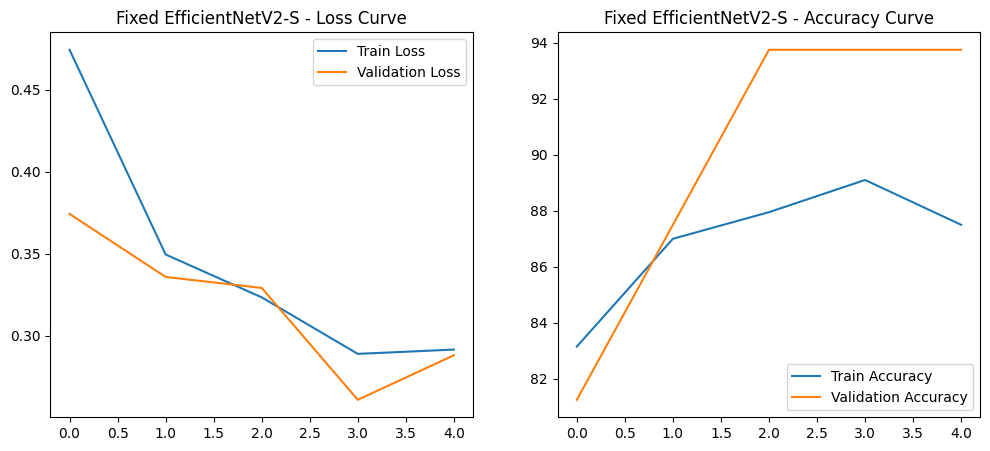

Test Accuracy (Fixed EfficientNetV2-S): 81.41%
Test Loss: 0.4192


In [5]:

#IMPORTS
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optims

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms.functional import InterpolationMode
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights  #EfficientNetV2-S

#DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

#Google Drive
from google.colab import drive
drive.mount('/content/drive')


#資料夾路徑
train_path = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
val_path   = '/content/drive/MyDrive/Colab Notebooks/chest_xray/val'
test_path  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'

#Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

common_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

#Datasets & DataLoaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_path,   transform=common_transform)
test_dataset  = datasets.ImageFolder(test_path,  transform=common_transform)

print("Train classes:", train_dataset.classes)
print("Val classes:",   val_dataset.classes)
print("Test classes:",  test_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

#建立EfficientNetV2-S模型（Task C:固定特徵）
model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

#修改最後一層為二分類輸出
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 1),
    nn.Sigmoid()
)

#凍結backbone，只訓練classifier[1]
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier[1].parameters():
    param.requires_grad = True

model = model.to(device)
print(model)

#Hyperparameters（只更新最後一層）
lr = 0.001
weight_decay = 0.0001
epochs = 5

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optims.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
criterion = nn.BCELoss()

lr_scheduler = optims.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=3, mode='max'
)

save = 'efficientnetv2s_fixed_hw4'

#train/val/test loop
def train_one_epoch(model, device, criterion, optimizer, train_loader):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.train()

    for images, labels in train_loader:
        gc.collect()
        if torch.cuda.is_available(): # Corrected: isAvailable -> is_available
            torch.cuda.empty_cache()

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels.unsqueeze(1))

        epoch_loss.append(loss.item())

        predicts = (preds > 0.5).float().view(-1).cpu().numpy()
        acc = accuracy_score(labels.cpu().numpy(), predicts)
        epoch_acc.append(acc)

        loss.backward()
        optimizer.step()

    return np.mean(epoch_loss), np.mean(epoch_acc)*100, time.time() - start


def val_one_epoch(model, device, criterion, val_loader, best_acc, save):
    epoch_loss = []
    epoch_acc = []
    start = time.time()

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            epoch_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            epoch_acc.append(acc)

    avg_acc = np.mean(epoch_acc)*100

    if avg_acc > best_acc:
        best_acc = avg_acc
        torch.save(model.state_dict(), f"{save}.pth")
        print(f"  >> Best Fixed EfficientNetV2-S Model Updated (Val Acc = {best_acc:.2f}%) Kishan")

    return np.mean(epoch_loss), avg_acc, time.time() - start, best_acc


def evaluate(model, device, model_path, test_loader):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    test_loss, test_acc = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images)
            loss = criterion(preds, labels.unsqueeze(1))
            test_loss.append(loss.item())

            predicts = (preds > 0.5).float().view(-1).cpu().numpy()
            acc = accuracy_score(labels.cpu().numpy(), predicts)
            test_acc.append(acc)

    print(f"Test Accuracy (Fixed EfficientNetV2-S): {np.mean(test_acc)*100:.2f}%")
    print(f"Test Loss: {np.mean(test_loss):.4f}")

    return np.mean(test_loss), np.mean(test_acc)*100

#主訓練迴圈
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0

for epoch in range(epochs):
    print(f"\n===== [Fixed EfficientNetV2-S] Epoch {epoch+1}/{epochs} =====")

    train_loss, train_acc, train_time = train_one_epoch(model, device, criterion, optimizer, train_loader)
    val_loss, val_acc, val_time, best_acc = val_one_epoch(model, device, criterion, val_loader, best_acc, save)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    lr_scheduler.step(val_acc)

#畫Loss/Accuracy曲線
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Fixed EfficientNetV2-S - Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Fixed EfficientNetV2-S - Accuracy Curve")
plt.legend()

plt.show()

#最後測試
model_path = 'efficientnetv2s_fixed_hw4.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)
